In [2]:
import os
import json
import numpy as np

from collections import Counter
import jellyfish
from tqdm import tqdm

from dataclasses import dataclass

SEQUENCE_LENGTH = 512
SEQUENCES_PER_SAMPLE = 10


BASE = "/Volumes/New Volume/malware-detection-dataset/opcodes"
files = [
    os.path.join(BASE, "data/", path)
    for path in os.listdir(os.path.join(BASE, "data"))
    if not path.startswith("._")
]

In [ ]:
ratio = []
total = []
unique = []


instructions = Counter()
loop = tqdm(files, desc="Creating Vocab")
for path in loop:
    obj = json.load(open(path, "r"))
    for opcode in obj:
        instructions[opcode] += 1
    ratio.append(len(instructions) / instructions.total())
    total.append(instructions.total())
    unique.append(len(instructions))
    loop.set_postfix(total=total[-1], unique=unique[-1], ratio=ratio[-1])

Creating Vocab: 100%|██████████| 9880/9880 [1:04:28<00:00,  2.55it/s, ratio=0.0792, total=7.72e+8, unique=6.11e+7]


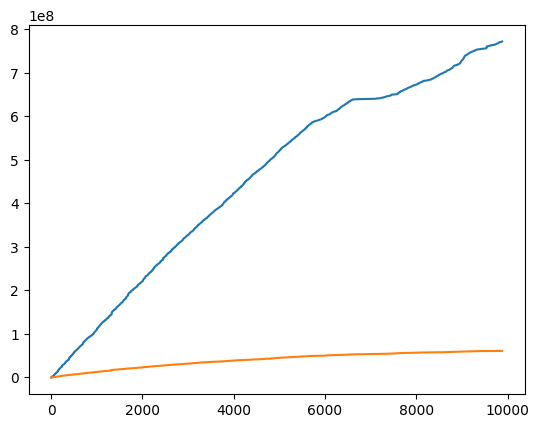

In [ ]:
import matplotlib.pyplot as plt

plt.plot(total)
plt.plot(unique)
plt.show()

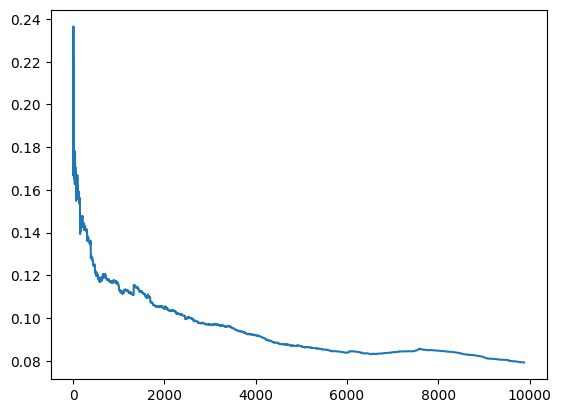

In [11]:
plt.plot(ratio)

In [14]:
instructions.most_common(10)

[('add byte [eax], al', 281541189),
 ('add byte [rax], al', 36642979),
 ('int3', 4850762),
 ('push eax', 3669565),
 ('nop', 3146927),
 ('ret', 2607940),
 ('outsd dx, dword [esi]', 2562666),
 ('push esi', 2481091),
 ('push ebx', 2472942),
 ('popal', 2413817)]

In [15]:
len(instructions)

61129186

In [ ]:
json.dump(
    instructions,
    open("/Volumes/New Volume/malware-detection-dataset/opcodes/frequency.json", "w"),
)